Notebook for building analysis of resulting synapse distribution

In [1]:
import os
import sys
sys.path.append("../")
sys.path.append("../Modules/")
import pandas as pd
import h5py

from Modules import analysis
from Modules import view_synapses

## Pick Simulation

In [2]:
sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-01-00-13-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0000_DepthDistalInh0.0000_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1100_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_1.2982_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-11-37-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-18-27-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-18-13-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-04-13-49-L23_5sec_STA_Rhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.2200_0.2200_0.1650_ExcTuftDensity2.1600_2.1600_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-04-14-11-L23_5sec_STA_Rhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhDens0.0220_0.0220_0.0165_ExcDens4.3200_4.3200_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-04-16-36-L23_5sec_STA_Rhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhDens0.2200_0.2200_0.2200_ExcDens1.6200_2.1600_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-31-21-15-Complex_50sec_STA/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1100_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_1.2982_Np5000"

In [3]:
save_folder = os.path.join(sim_dir, 'synapse_distribution')

if not os.path.exists(save_folder):
    os.mkdir(save_folder)

## Loading Data

Read files

In [4]:
# read synapses from simulation
syn_data = view_synapses.read_synapse_distribution_file(sim_dir)

# read segment data from simulation
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))

# read transfer impedances
imp_df = view_synapses.read_transfer_impedance_file(sim_dir, loc='soma')
seg_data['soma_trans_imp'] = imp_df.beta_active

# add segment information of synapse location
syn_data = view_synapses.add_seg_info_to_syn_data(syn_data, seg_data)

Choose transfer impedance for analysis

In [5]:
# choose transfer impedance
seg_data['soma_trans_imp'] = imp_df.beta_active

Check that the seg indices correspond

In [6]:
# checks
if len(seg_data) != len(imp_df):
    IndexError(f"{len(seg_data)} != {max(syn_data.seg_id)}. The imp_df does not correspond to seg_data")
if len(seg_data) != max(syn_data.seg_id):
    print(f"{len(seg_data)} != {max(syn_data.seg_id)} need to check that syn_data.seg_id actually corresponds to seg_data row index.")

2630 != 2507 need to check that syn_data.seg_id actually corresponds to seg_data row index.


Previews

In [7]:
seg_data

,Unnamed: 0,section,idx_in_section_type,seg_half_seg_RA,L,seg,pseg,Section_L,Section_diam,Distance,...,pc_1,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,soma_trans_imp
0,0,soma,0,0.081276,23.169408,L5PCtemplate[0].soma[0](0.5),None,23.169408,13.471518,0.000000,...,18.343678,-50.250000,57.287731,19.065830,-50.250000,6.735759,23.124348,1.444304,0.000000,1.000000
1,1,dend,0,2.647135,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,20.787594,-50.027254,61.001504,21.408927,-49.444755,0.539452,4.591504,1.178928,0.805245,0.929486
2,2,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,21.939324,-50.557475,64.964606,21.737526,-51.687077,0.585000,3.963102,0.328599,-2.242322,0.851091
3,3,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,21.040891,-51.991813,68.301396,20.356904,-50.119401,0.585000,3.336790,-1.380622,1.567676,0.781747
4,4,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,19.672918,-48.246989,70.726764,18.807201,-46.252588,0.585000,2.425368,-1.549704,3.866813,0.720767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,2625,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.653846),L5PCtemplate[0].axon[0](0.576923),60.000004,1.000000,39.230772,...,57.574449,-50.250000,45.725559,59.882142,-50.250000,0.500000,0.000000,4.615385,0.000000,0.436135
2626,2626,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.730769),L5PCtemplate[0].axon[0](0.653846),60.000004,1.000000,43.846157,...,62.189834,-50.250000,45.725559,64.497527,-50.250000,0.500000,0.000000,4.615385,0.000000,0.406617
2627,2627,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.807692),L5PCtemplate[0].axon[0](0.730769),60.000004,1.000000,48.461542,...,66.805219,-50.250000,45.725559,69.112912,-50.250000,0.500000,0.000000,4.615385,0.000000,0.380675
2628,2628,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.884615),L5PCtemplate[0].axon[0](0.807692),60.000004,1.000000,53.076926,...,71.420604,-50.250000,45.725559,73.728296,-50.250000,0.500000,0.000000,4.615385,0.000000,0.357720


In [8]:
syn_data

,mean_firing_rate,pc_name,seg_id,synapse_type,weight,Distance,section,soma_trans_imp,seg_L
0,15.14,b'fg_4_cell49',2465,inh_perisomatic,4.594687,254.028500,apic,0.092785,4.771715
1,15.14,b'fg_4_cell49',1032,inh_perisomatic,4.707115,17.959876,dend,0.711726,4.369302
2,12.44,b'fg_4_cell32',870,inh_perisomatic,4.554103,110.889808,dend,0.104306,4.963371
3,16.46,b'fg_4_cell45',981,inh_perisomatic,4.267442,79.153520,dend,0.189519,4.166857
4,18.28,b'fg_4_cell27',994,inh_perisomatic,4.598666,142.410511,dend,0.029432,4.893885
...,...,...,...,...,...,...,...,...,...
12430,6.64,b'fg_5_cell93',832,exc_distal_basal,1.243313,159.384125,dend,0.064418,4.871511
12431,12.98,b'fg_6_cell10',435,exc_distal_basal,1.384900,31.350641,dend,0.470124,4.635930
12432,3.22,b'fg_5_cell45',817,exc_distal_basal,1.261324,86.311456,dend,0.145326,4.871511
12433,7.38,b'fg_5_cell65',814,exc_distal_basal,1.125315,71.696922,dend,0.192455,4.871511


## Plotting on Morphology

In [9]:
import pandas as pd

# Assume df is your existing dataframe
# Example: Create a column that classifies synapses as 'exc' or 'inh'
syn_data['synapse_class'] = syn_data['synapse_type'].apply(lambda x: 'exc' if x.startswith('exc') else ('inh' if x.startswith('inh') else None))

# Filter the dataframe into excitatory and inhibitory synapses
df_exc = syn_data[syn_data['synapse_class'] == 'exc']
df_inh = syn_data[syn_data['synapse_class'] == 'inh']

# Group by 'seg_id' and aggregate all other columns into lists
df_exc_grouped = df_exc.groupby('seg_id').agg(lambda x: list(x)).reset_index()
df_inh_grouped = df_inh.groupby('seg_id').agg(lambda x: list(x)).reset_index()

# Display the resulting dataframes
print("Excitatory synapses grouped by segment:")
print(df_exc_grouped)
print("\nInhibitory synapses grouped by segment:")
print(df_inh_grouped)


Excitatory synapses grouped by segment:
      seg_id                                   mean_firing_rate  \
0         11                                     [12.98, 12.98]   
1         12                       [11.56, 11.56, 11.56, 11.56]   
2         13  [6.819999999999999, 6.819999999999999, 6.81999...   
3         14         [5.88, 5.88, 5.88, 5.88, 5.88, 5.88, 5.88]   
4         15         [7.08, 7.08, 7.08, 7.08, 7.08, 7.08, 7.08]   
...      ...                                                ...   
2091    2501                                             [2.66]   
2092    2503                           [10.6, 10.6, 10.6, 10.6]   
2093    2504                  [9.879999999999999, 10.08, 10.08]   
2094    2505                                              [5.7]   
2095    2506             [4.859999999999999, 4.859999999999999]   

                                                pc_name  \
0                    [b'fg_43_cell23', b'fg_43_cell23']   
1     [b'fg_43_cell75', b'fg_43_cell7

In [10]:
import numpy as np
for df in [df_exc_grouped, df_inh_grouped]:

    df['seg_L'] = df['seg_L'].apply(np.mean)
    df['pc_name'] = np.array(df['pc_name'].apply(np.array))
    df['num_syns'] = df['pc_name'].apply(len)
    df['num_cells'] = df['pc_name'].apply(np.unique).apply(len) # number of cells per segment
    df['weight_mean'] = df['weight'].apply(np.mean) # mean weight
    df['weight_std'] = df['weight'].apply(np.std) # mean weight
    df['weight_sum'] = df['weight'].apply(np.sum) # mean weight

    # do same for fr
    df['fr_mean'] = df['mean_firing_rate'].apply(np.mean) # mean weight
    df['fr_std'] = df['mean_firing_rate'].apply(np.std) # mean weight
    df['fr_sum'] = df['mean_firing_rate'].apply(np.sum) # mean weight

    # Multiply weight and firing rate and sum
    df['weightXfr'] = df.apply(lambda row: [a * b for a, b in zip(row['weight'], row['mean_firing_rate'])], axis=1)
    df['weightXfr_sum'] = df['weightXfr'].apply(np.sum) # mean weight

    df['syn_density'] = df.apply(lambda row: [row['num_syns'] / row['seg_L']], axis=1)
    df['syn_density'] = [row[0] for row in df['syn_density']]

    # remove duplicates
    # df['section'] = df['section'].apply(np.unique)
    df['Distance'] = [row[0] if len(row) == 1 else ValueError('expecting one unique value in row') for row in df['Distance'].apply(np.unique)]

# df_exc_grouped[[row[0] == 'dend' for row in df_exc_grouped['section'].apply(np.unique)]] # subset by basal segments

In [11]:
len([row[0] if len(row) == 1 else ValueError('expecting one unique value in row') for row in df_exc_grouped['Distance'].apply(np.unique)]) # subset by basal segments

2096

In [12]:
df_inh_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,2,[11.02],[b'fg_4_cell29'],[inh_perisomatic],[4.806867489305153],7.260263,[dend],[0.8510913839976284],4.840176,[inh],...,1,4.806867,0.000000,4.806867,11.02,0.0,11.02,[52.97167973214279],52.971680,0.206604
1,3,"[17.840000000000003, 17.840000000000003, 17.84...","[b'fg_0_cell16', b'fg_0_cell16', b'fg_0_cell16']","[inh_perisomatic, inh_perisomatic, inh_perisom...","[4.30867119340389, 4.788614920464348, 4.552386...",12.100439,"[dend, dend, dend]","[0.7817472641620662, 0.7817472641620662, 0.781...",4.840176,"[inh, inh, inh]",...,1,4.549891,0.195944,13.649673,17.84,0.0,53.52,"[76.86669409032541, 85.42889018108399, 81.2145...",243.510160,0.619812
2,4,"[17.840000000000003, 17.840000000000003]","[b'fg_0_cell16', b'fg_0_cell16']","[inh_perisomatic, inh_perisomatic]","[4.458424933129539, 4.672454284617947]",16.940615,"[dend, dend]","[0.7207665360049649, 0.7207665360049649]",4.840176,"[inh, inh]",...,1,4.565440,0.107015,9.130879,17.84,0.0,35.68,"[79.53830080703099, 83.35658443758419]",162.894885,0.413208
3,5,[17.840000000000003],[b'fg_0_cell16'],[inh_perisomatic],[4.714071690383398],21.780790,[dend],[0.6671984241317321],4.840176,[inh],...,1,4.714072,0.000000,4.714072,17.84,0.0,17.84,[84.09903895643984],84.099039,0.206604
4,6,[17.840000000000003],[b'fg_0_cell16'],[inh_perisomatic],[4.533078980386736],26.098653,[dend],[0.6114098184201815],3.795549,[inh],...,1,4.533079,0.000000,4.533079,17.84,0.0,17.84,[80.87012901009939],80.870129,0.263466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,2503,"[20.88, 20.88]","[b'fg_4_cell35', b'fg_4_cell35']","[inh_oblique, inh_oblique]","[1.8416573353670413, 1.8288974614382303]",226.622336,"[apic, apic]","[0.1513696227505099, 0.1513696227505099]",4.981013,"[inh, inh]",...,1,1.835277,0.006380,3.670555,20.88,0.0,41.76,"[38.45380516246382, 38.18737899483025]",76.641184,0.401525
1828,2504,[12.5],[b'fg_4_cell11'],[inh_oblique],[1.850882448535818],231.603349,[apic],[0.1374426165981383],4.981013,[inh],...,1,1.850882,0.000000,1.850882,12.50,0.0,12.50,[23.136030606697723],23.136031,0.200762
1829,2505,"[12.5, 12.5]","[b'fg_4_cell11', b'fg_4_cell11']","[inh_oblique, inh_oblique]","[1.8682495631089258, 1.9883562951349991]",236.584362,"[apic, apic]","[0.1258277634196074, 0.1258277634196074]",4.981013,"[inh, inh]",...,1,1.928303,0.060053,3.856606,12.50,0.0,25.00,"[23.353119538861574, 24.85445368918749]",48.207573,0.401525
1830,2506,"[12.5, 12.5, 12.5, 12.5]","[b'fg_4_cell11', b'fg_4_cell11', b'fg_4_cell11...","[inh_oblique, inh_oblique, inh_oblique, inh_ob...","[1.9461756841523397, 1.929738532776595, 1.8495...",241.565374,"[apic, apic, apic, apic]","[0.1159951420116688, 0.1159951420116688, 0.115...",4.981013,"[inh, inh, inh, inh]",...,1,1.857708,0.095246,7.430833,12.50,0.0,50.00,"[24.327196051904245, 24.12173165970744, 23.119...",92.885408,0.803050


In [13]:
df_exc_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,11,"[12.98, 12.98]","[b'fg_43_cell23', b'fg_43_cell23']","[exc_distal_basal, exc_distal_basal]","[1.2925702008132283, 1.033076926167647]",46.721029,"[dend, dend]","[0.3324135134321044, 0.3324135134321044]",4.891969,"[exc, exc]",...,1,1.162824,0.129747,2.325647,12.980000,0.000000e+00,25.96,"[16.777561206555703, 13.409338501656057]",30.186900,0.408833
1,12,"[11.56, 11.56, 11.56, 11.56]","[b'fg_43_cell75', b'fg_43_cell75', b'fg_43_cel...","[exc_distal_basal, exc_distal_basal, exc_dista...","[1.1606995239707125, 0.917113083562761, 1.0860...",51.612998,"[dend, dend, dend, dend]","[0.2819834556992703, 0.2819834556992703, 0.281...",4.891969,"[exc, exc, exc, exc]",...,1,1.127531,0.154073,4.510126,11.560000,0.000000e+00,46.24,"[13.417686497101437, 10.601827245985518, 12.55...",52.137054,0.817667
2,13,"[6.819999999999999, 6.819999999999999, 6.81999...","[b'fg_6_cell3', b'fg_6_cell3', b'fg_6_cell3', ...","[exc_distal_basal, exc_distal_basal, exc_dista...","[1.20526045171225, 1.3859048261835645, 1.25165...",56.504967,"[dend, dend, dend, dend, dend]","[0.2445401036871202, 0.2445401036871202, 0.244...",4.891969,"[exc, exc, exc, exc, exc]",...,1,1.259448,0.079468,6.297242,6.820000,8.881784e-16,34.10,"[8.219876280677545, 9.45187091457191, 8.536262...",42.947191,1.022083
3,14,"[5.88, 5.88, 5.88, 5.88, 5.88, 5.88, 5.88]","[b'fg_6_cell53', b'fg_6_cell53', b'fg_6_cell53...","[exc_distal_basal, exc_distal_basal, exc_dista...","[0.898807109148231, 1.0948430962346323, 1.1204...",61.396937,"[dend, dend, dend, dend, dend, dend, dend]","[0.2157142672891647, 0.2157142672891647, 0.215...",4.891969,"[exc, exc, exc, exc, exc, exc, exc]",...,1,1.101413,0.124197,7.709888,5.880000,8.881784e-16,41.16,"[5.284985801791598, 6.437677405859637, 6.58806...",45.334144,1.430917
4,15,"[7.08, 7.08, 7.08, 7.08, 7.08, 7.08, 7.08]","[b'fg_6_cell22', b'fg_6_cell22', b'fg_6_cell22...","[exc_distal_basal, exc_distal_basal, exc_dista...","[0.9211923941534134, 1.5, 1.287218012946741, 1...",66.288906,"[dend, dend, dend, dend, dend, dend, dend]","[0.1928719520071796, 0.1928719520071796, 0.192...",4.891969,"[exc, exc, exc, exc, exc, exc, exc]",...,1,1.204843,0.165972,8.433900,7.080000,8.881784e-16,49.56,"[6.5220421506061665, 10.620000000000001, 9.113...",59.712010,1.430917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091,2501,[2.66],[b'fg_34_cell14'],[exc_oblique],[1.4146962643883751],216.660311,[apic],[0.1693311887191135],4.981013,[exc],...,1,1.414696,0.000000,1.414696,2.660000,0.000000e+00,2.66,[3.763092063273078],3.763092,0.200762
2092,2503,"[10.6, 10.6, 10.6, 10.6]","[b'fg_34_cell38', b'fg_34_cell38', b'fg_34_cel...","[exc_oblique, exc_oblique, exc_oblique, exc_ob...","[1.4272153322544405, 1.0892494547455536, 1.282...",226.622336,"[apic, apic, apic, apic]","[0.1513696227505099, 0.1513696227505099, 0.151...",4.981013,"[exc, exc, exc, exc]",...,1,1.248260,0.123912,4.993041,10.600000,0.000000e+00,42.40,"[15.12848252189707, 11.546044220302868, 13.594...",52.926231,0.803050
2093,2504,"[9.879999999999999, 10.08, 10.08]","[b'fg_34_cell99', b'fg_34_cell5', b'fg_34_cell5']","[exc_oblique, exc_oblique, exc_oblique]","[1.1228022703576266, 1.1381660677217489, 1.325...",231.603349,"[apic, apic, apic]","[0.1374426165981383, 0.1374426165981383, 0.137...",4.981013,"[exc, exc, exc]",...,2,1.195528,0.092200,3.586585,10.013333,9.428090e-02,30.04,"[11.09328643113335, 11.472713962635229, 13.362...",35.928219,0.602287
2094,2505,[5.7],[b'fg_34_cell58'],[exc_oblique],[1.112280284460374],236.584362,[apic],[0.1258277634196074],4.981013,[exc],...,1,1.112280,0.000000,1.112280,5.700000,0.000000e+00,5.70,[6.339997621424132],6.339998,0.200762


In [14]:
import matplotlib.pyplot as plt
def plot_var_on_morph_for_both_syn_types(df_inh:pd.DataFrame,
                                         df_exc:pd.DataFrame,
                                         var:str,
                                         cbar_label:str,
                                         title_suffix:str,
                                         save_folder:str,
                                         clim_max):
    # clim_maxes = [4, 20]
    radius_scale=5
    fig, axes = plt.subplots(1, 2, figsize=(24, 12), subplot_kw={'projection': '3d'})
    for i,syn_type, syn_df in zip([0,1],['inh', 'exc'], [df_inh, df_exc]):

        # ours_syn_data_by_this_syntype = syn_data[syn_data['synapse_type'].str.contains(syn_type, na=False)]

        # synapse_counts_ours = view_synapses.build_synapse_counts_dict(ours_syn_data_by_this_syntype, seg_id_column='seg_id')
        # synapse_counts_bens.pop(0) # remove soma segment since it has way more synapses 
        # synapse_counts_ours.pop(0) # remove soma segment since it has way more synapses 
        title = f"{syn_type} {title_suffix}"
        var_dict = syn_df.set_index('seg_id')[var].to_dict()

        # for ax, title, synapse_counts in zip(axes, titles, synapse_counts_dicts):
        view_synapses.plot_morphology(seg_data,  #seg_data[seg_data['section']=='dend'], 
                                    seg_id_column='seg_id', 
                                        variable_dict=var_dict, 
                                        ax=axes[i], 
                                    #   elevation=elevation,
                                    #   azimuth=azimuth,
                                        radius_scale= radius_scale,
                                        title= title,
                                        clim_max= clim_max,
                                        cbar_label = cbar_label
                                        )
        
    plt.tight_layout()
    fig.savefig(os.path.join(save_folder, f'{var}.png'),dpi=300)

Total Input

In [15]:
# max(df_inh_grouped['weight_mean'].max(), df_exc_grouped['weight_mean'].max())

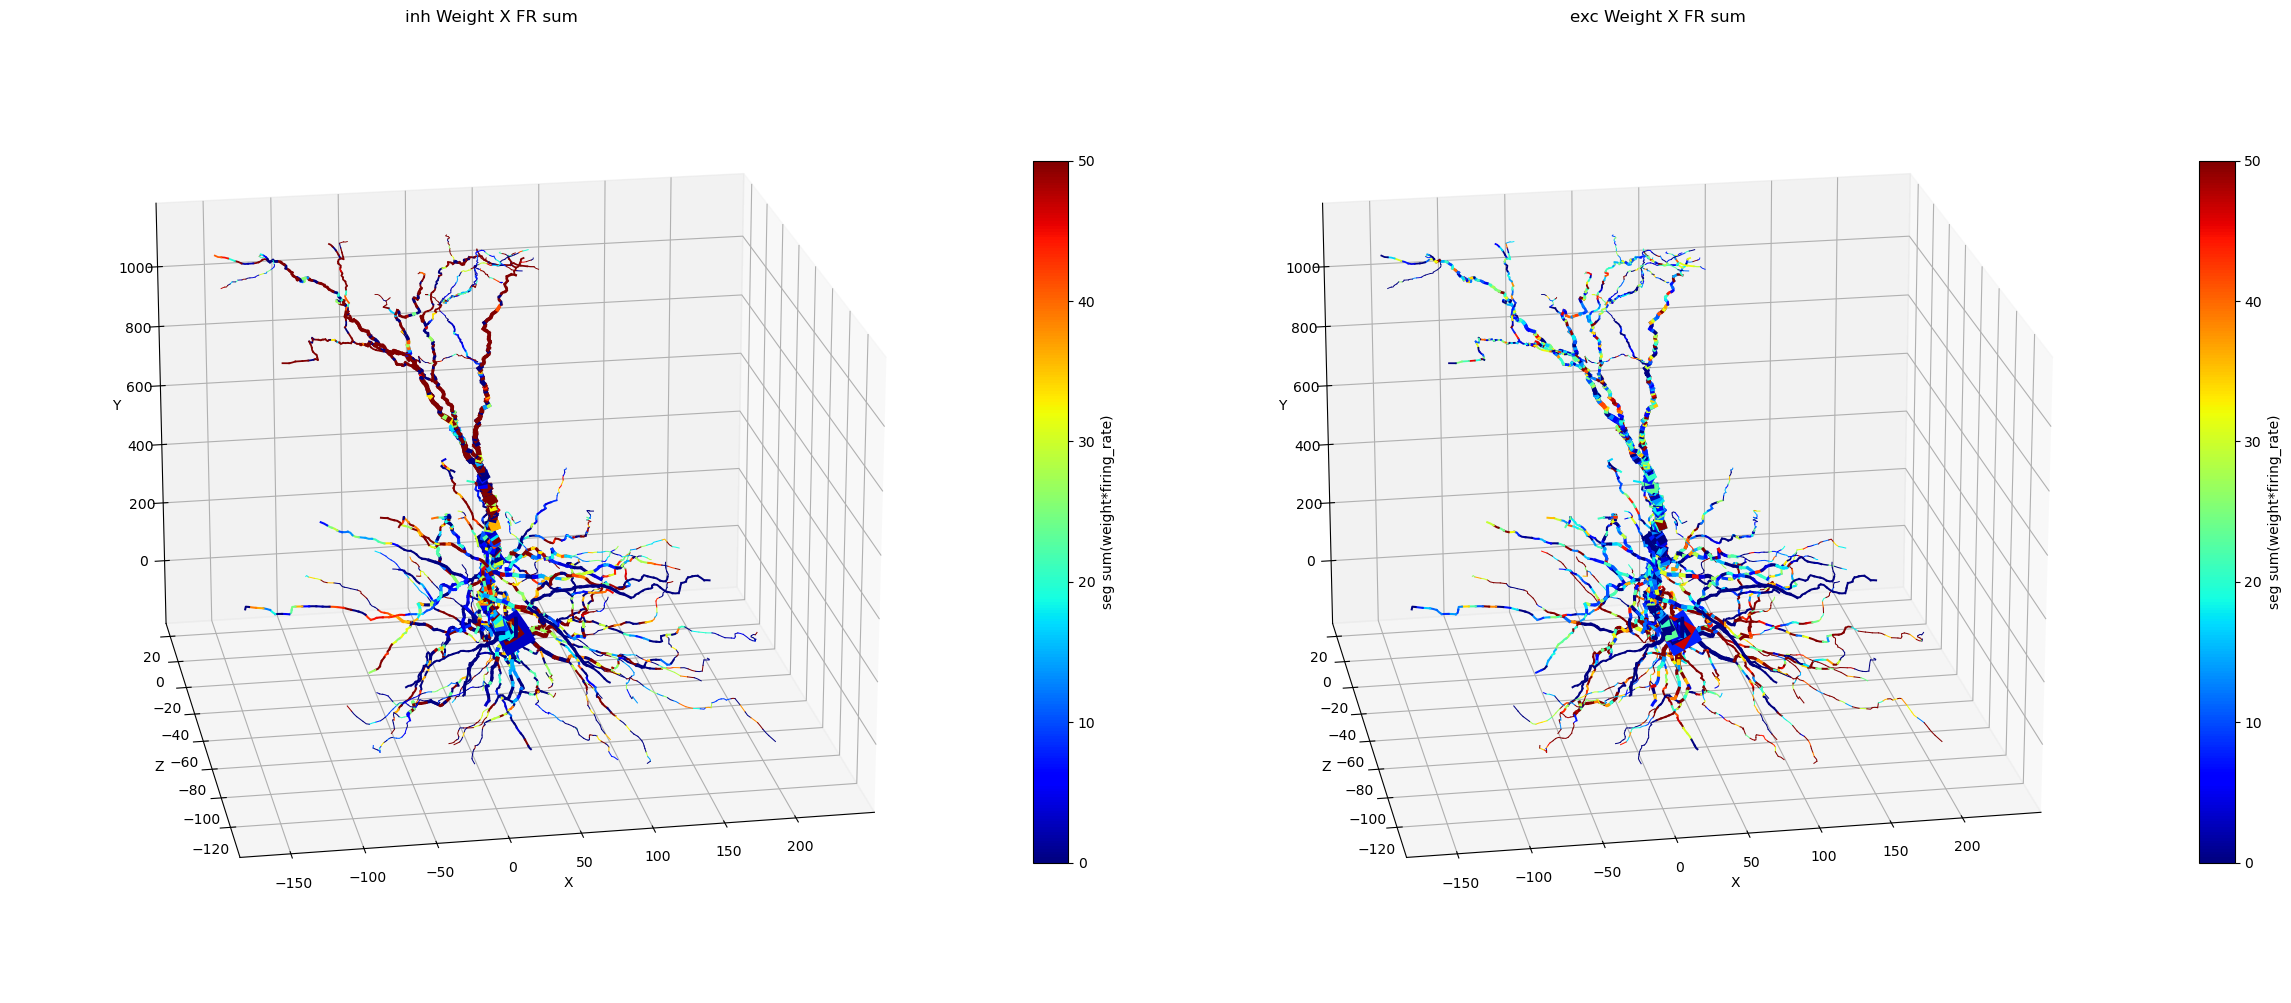

In [16]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='weightXfr_sum',
                                         cbar_label='seg sum(weight*firing_rate)',
                                         title_suffix='Weight X FR sum',
                                         save_folder=save_folder,
                                         clim_max = 50)

Firing Rate

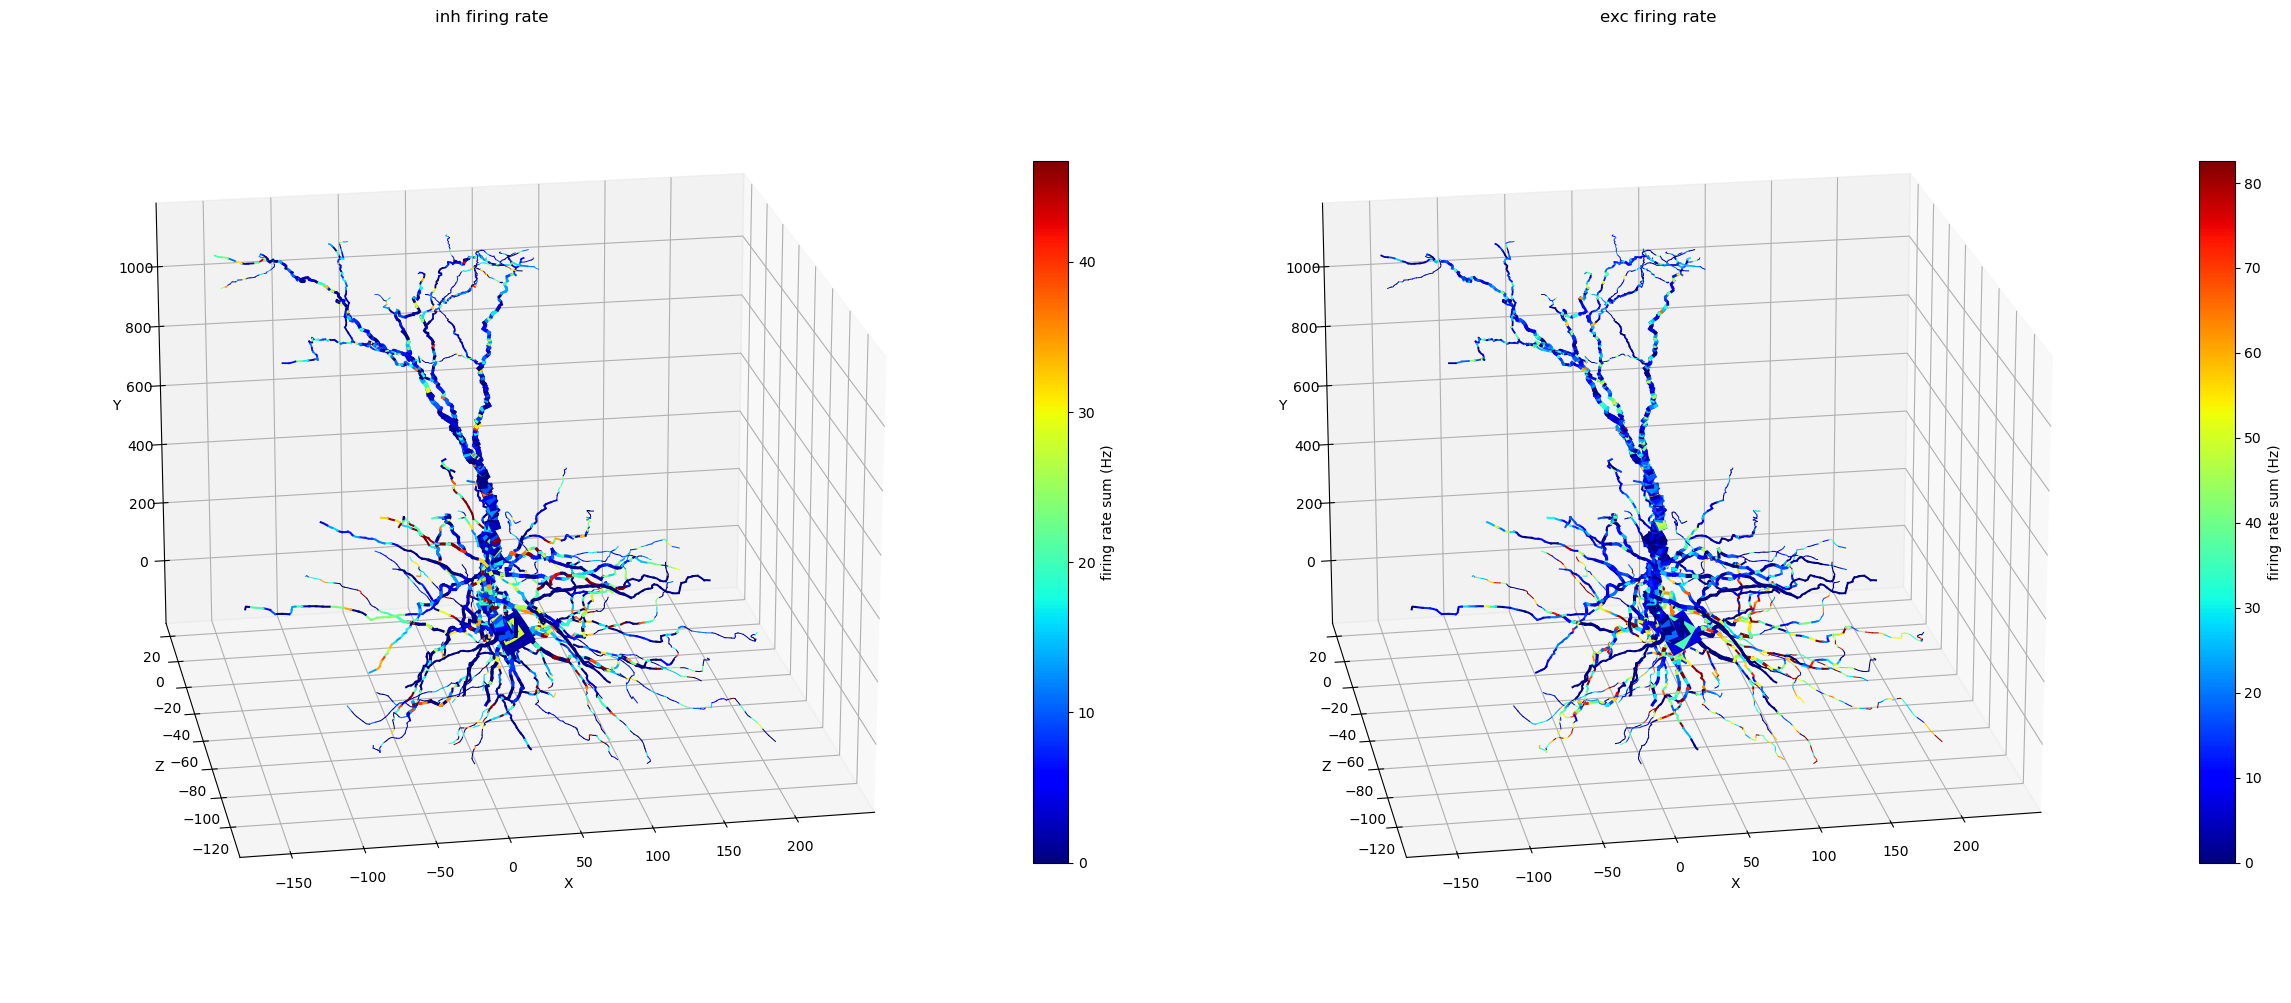

In [17]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='fr_sum',
                                         cbar_label='firing rate sum (Hz)',
                                         title_suffix='firing rate',
                                         save_folder=save_folder,
                                         clim_max = None)

synapse density

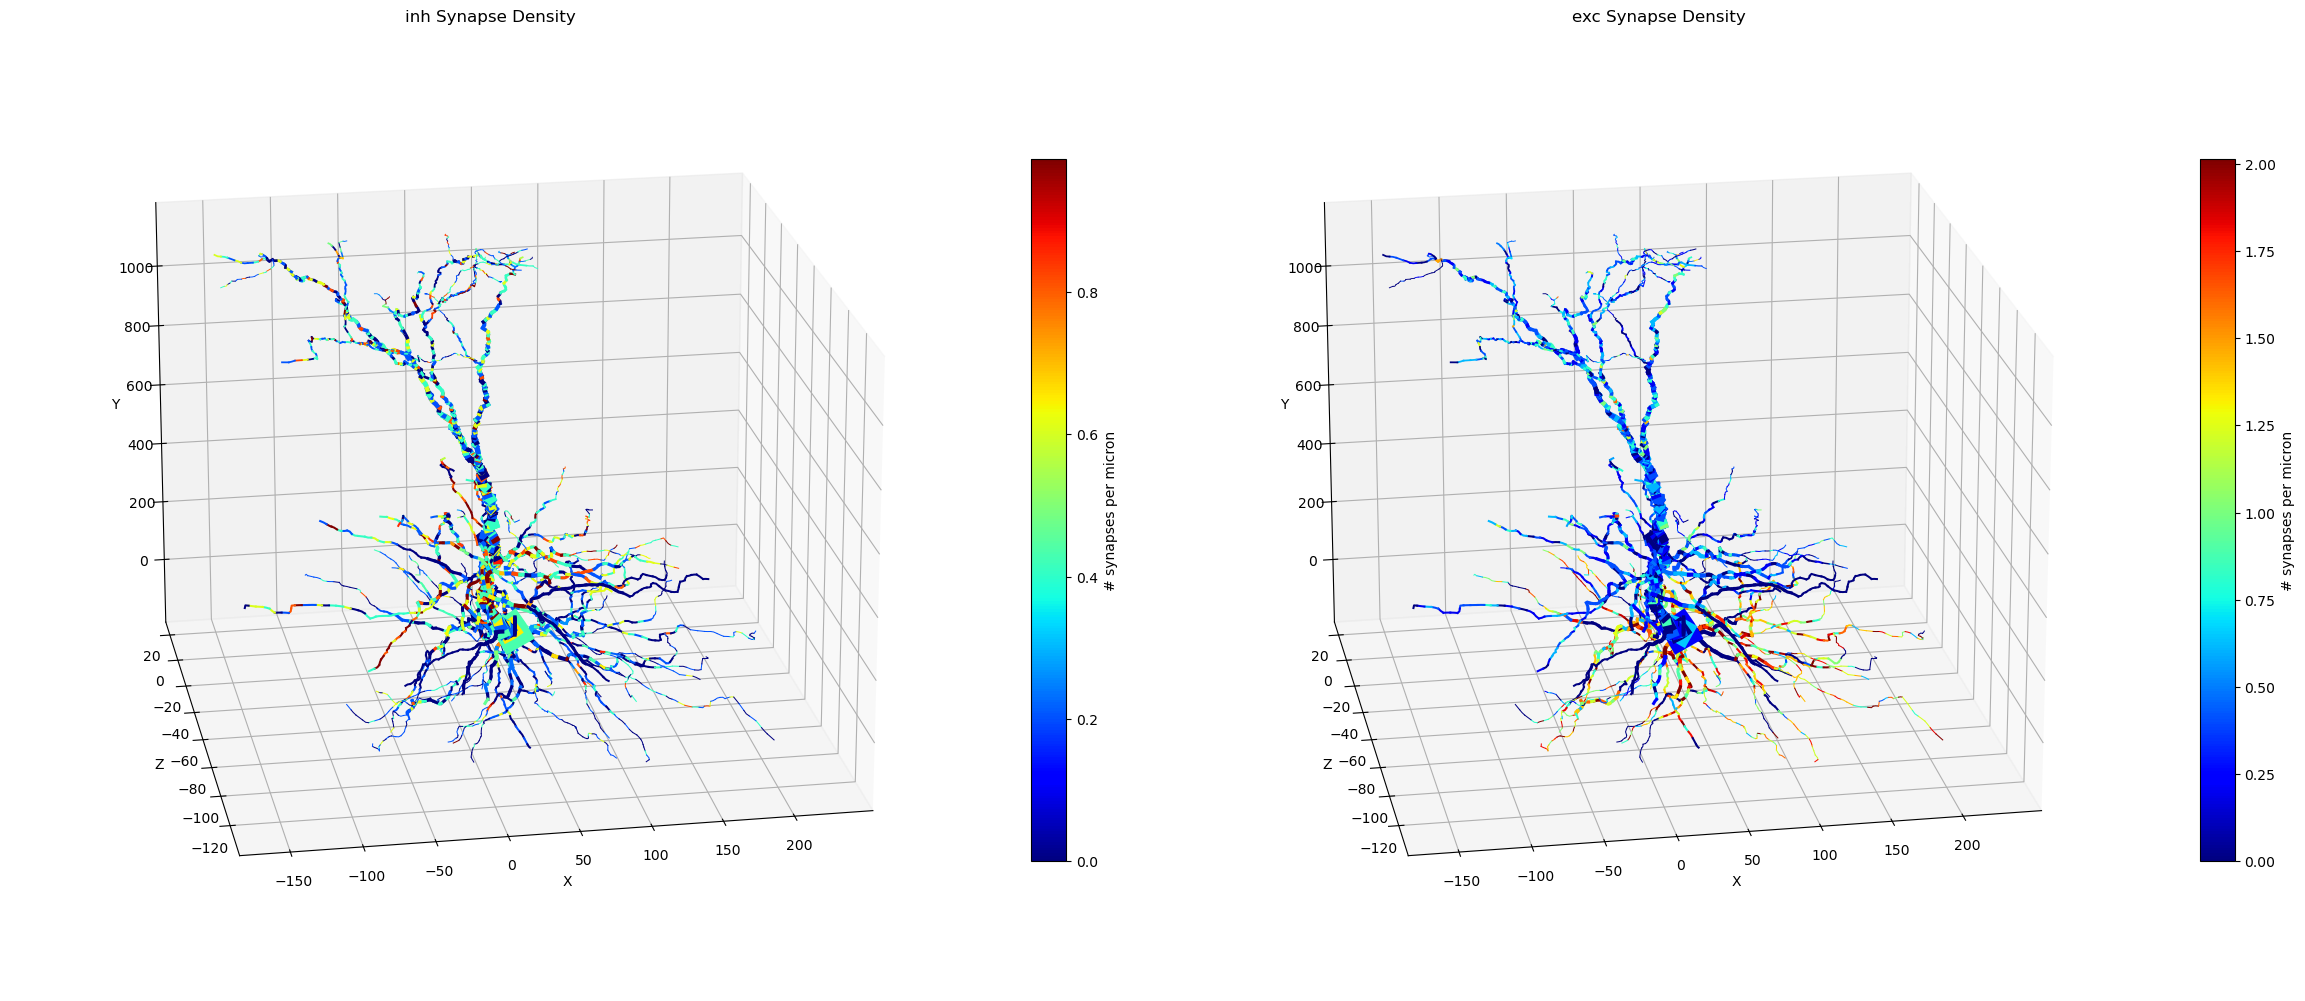

In [18]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='syn_density',
                                         cbar_label='# synapses per micron',
                                         title_suffix='Synapse Density',
                                         save_folder=save_folder,
                                         clim_max=None)

number of synapses

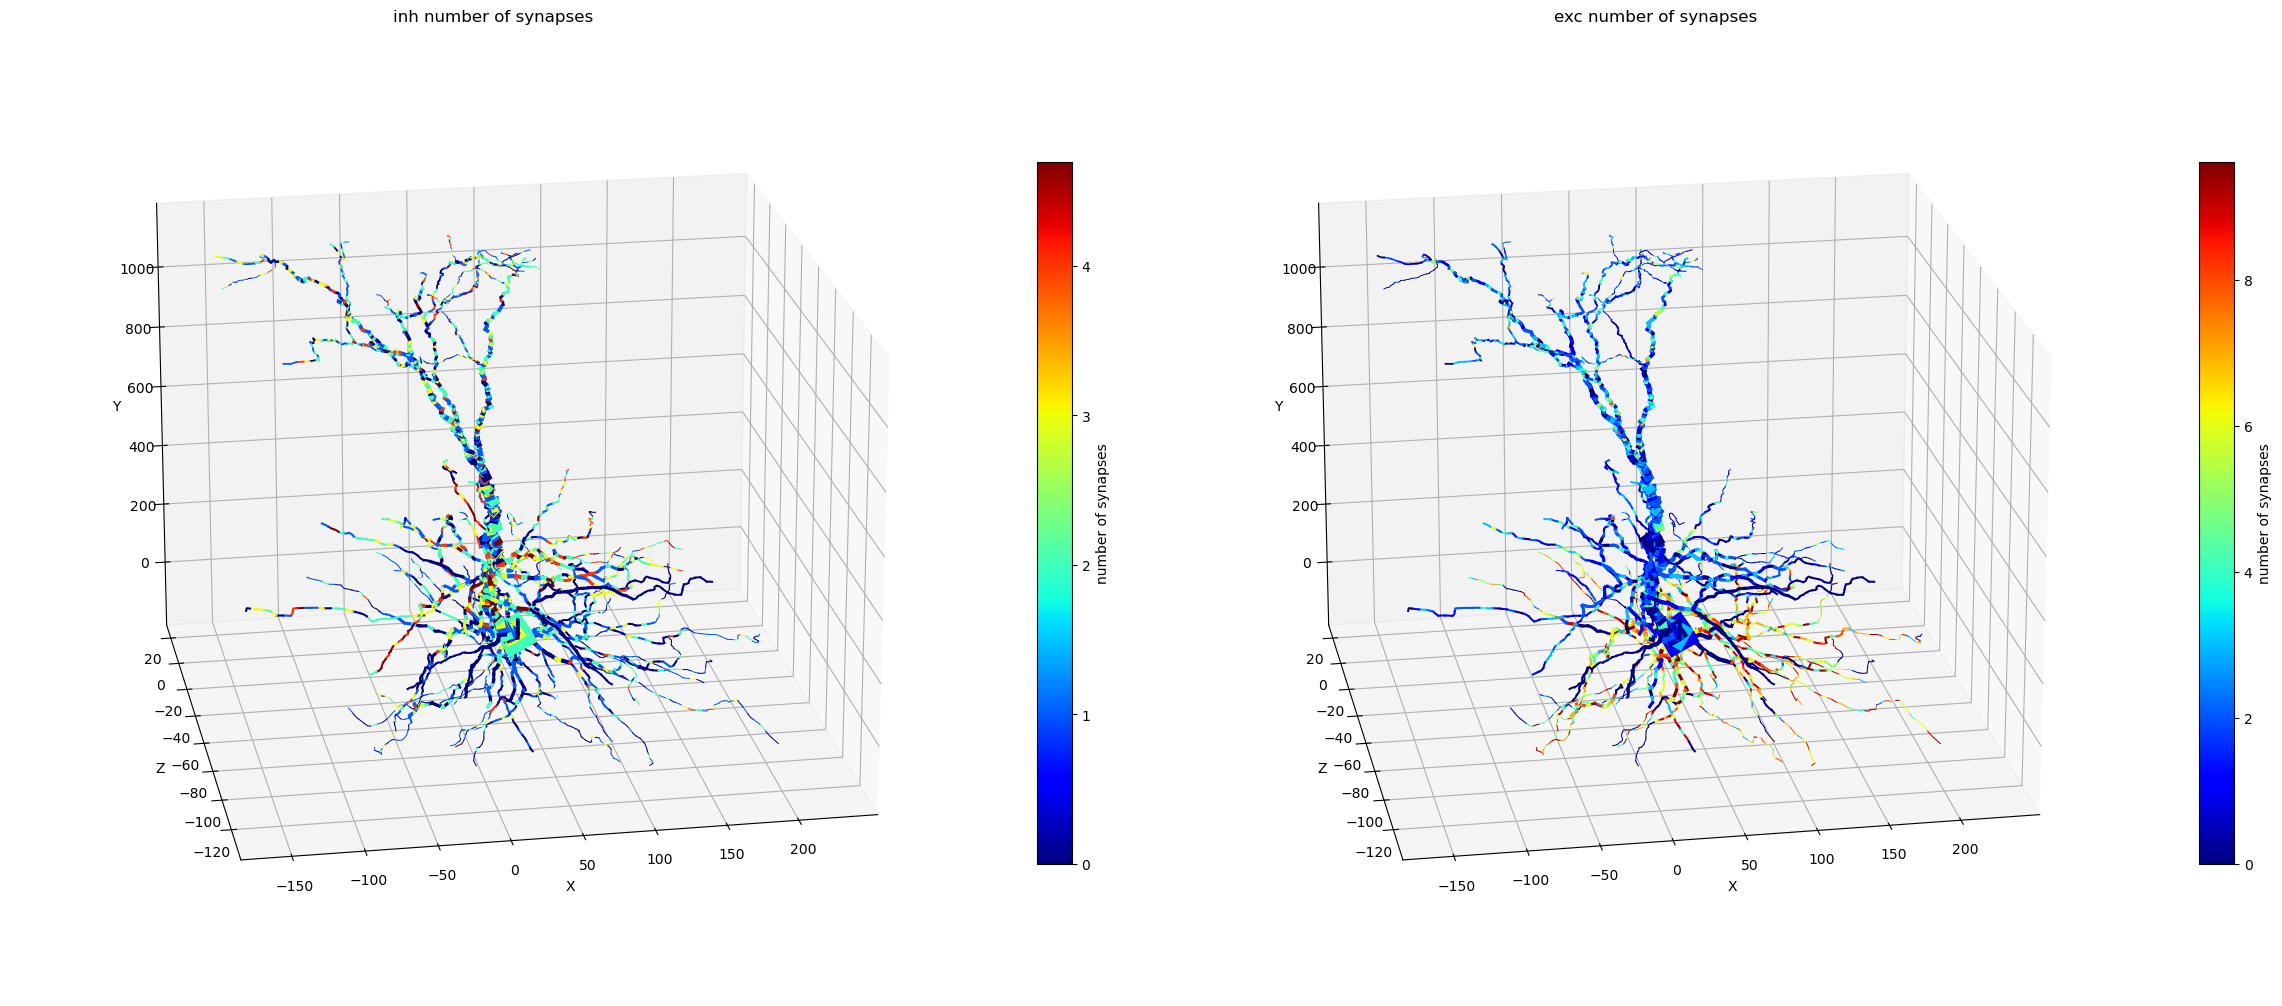

In [19]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='num_syns',
                                         cbar_label='number of synapses',
                                         title_suffix='number of synapses',
                                         save_folder=save_folder,
                                         clim_max=None)

In [20]:
np.shape(seg_data)

(2630, 24)

In [21]:
np.shape(df_exc_grouped)

(2096, 21)

2D plots

In [22]:
df_exc_grouped.columns

Index(['seg_id', 'mean_firing_rate', 'pc_name', 'synapse_type', 'weight',
       'Distance', 'section', 'soma_trans_imp', 'seg_L', 'synapse_class',
       'num_syns', 'num_cells', 'weight_mean', 'weight_std', 'weight_sum',
       'fr_mean', 'fr_std', 'fr_sum', 'weightXfr', 'weightXfr_sum',
       'syn_density'],
      dtype='object')

In [23]:
np.unique(df_exc_grouped['Distance'])

array([   1.8874751 ,    1.97190313,    2.08264668, ..., 1286.69128014,
       1288.36666482, 1293.23339955])

In [24]:
df_exc_grouped['syn_density']

0       0.408833
1       0.817667
2       1.022083
3       1.430917
4       1.430917
          ...   
2091    0.200762
2092    0.803050
2093    0.602287
2094    0.200762
2095    0.401525
Name: syn_density, Length: 2096, dtype: float64

In [25]:
df_exc_grouped['syn_density']

0       0.408833
1       0.817667
2       1.022083
3       1.430917
4       1.430917
          ...   
2091    0.200762
2092    0.803050
2093    0.602287
2094    0.200762
2095    0.401525
Name: syn_density, Length: 2096, dtype: float64

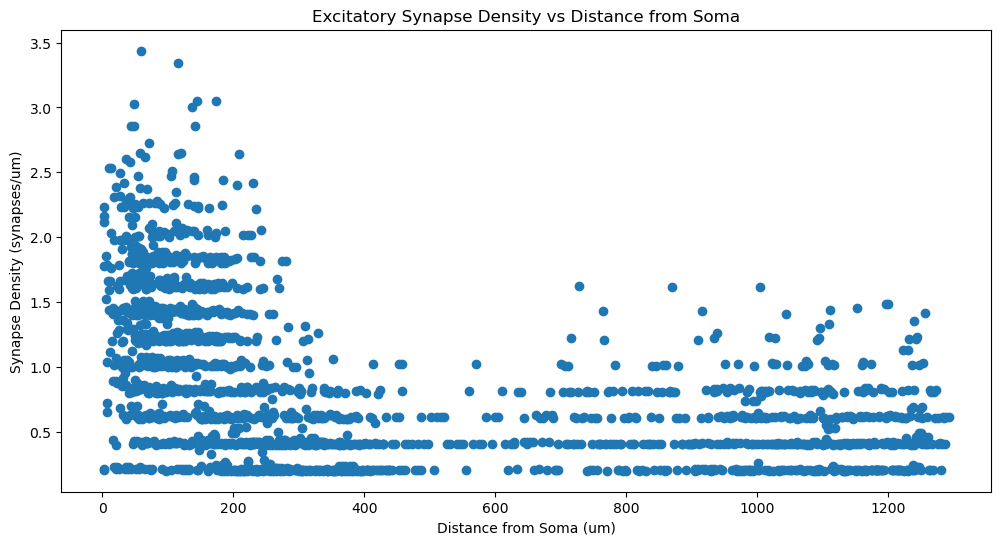

<Figure size 640x480 with 0 Axes>

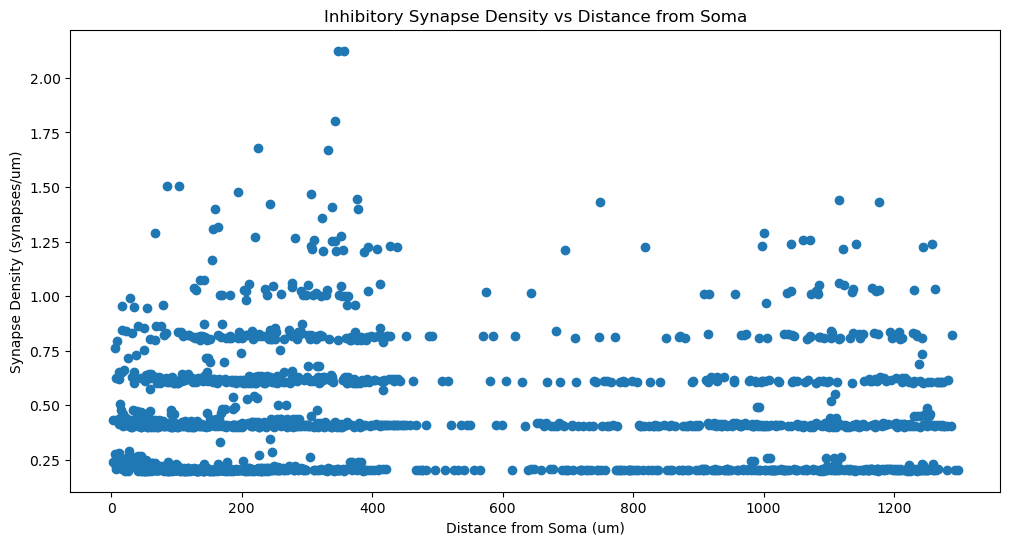

<Figure size 640x480 with 0 Axes>

In [26]:
# synapse density as a function of distance from soma
import matplotlib.pyplot as plt

for df, title_prefix in zip([df_exc_grouped, df_inh_grouped], ['Excitatory', 'Inhibitory']):
    # print(f"Plotting {title_prefix} synapse density vs distance from soma")
    plt.figure(figsize=(12, 6))
    plt.title(f'{title_prefix} Synapse Density vs Distance from Soma')
    plt.xlabel('Distance from Soma (um)')
    plt.ylabel('Synapse Density (synapses/um)')
    plt.scatter(df['Distance'], df['syn_density'])
    plt.show()
    plt.savefig(os.path.join(save_folder, f'{title_prefix}_synapse_density_vs_distance_2D.png'), dpi=300)

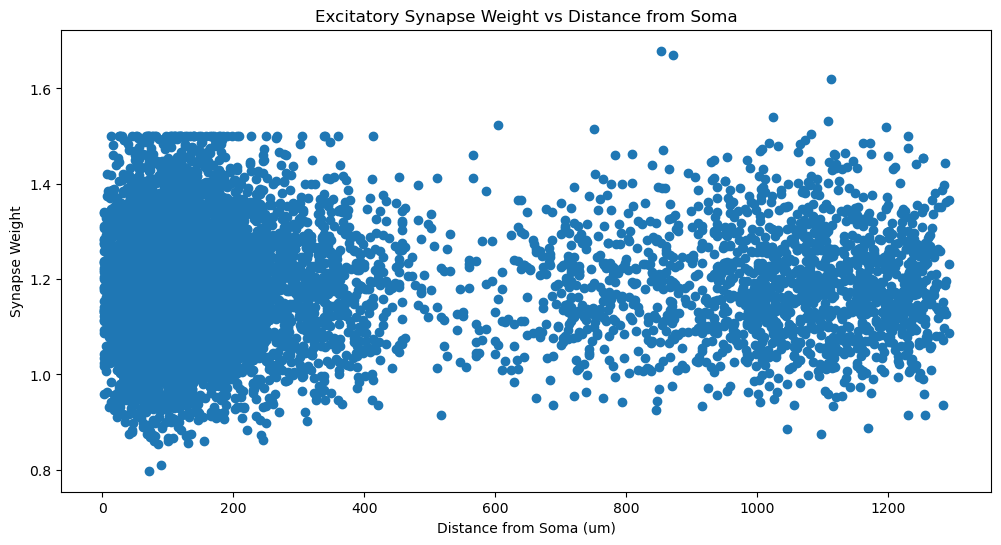

<Figure size 640x480 with 0 Axes>

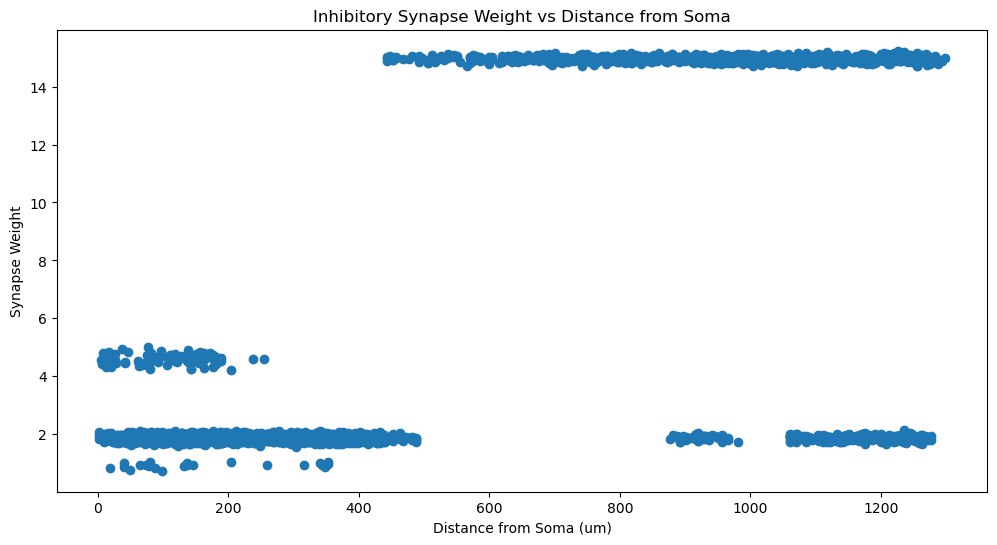

<Figure size 640x480 with 0 Axes>

In [27]:
for df, title_prefix in zip([df_exc_grouped, df_inh_grouped], ['Excitatory', 'Inhibitory']):
    # print(f"Plotting {title_prefix} synapse density vs distance from soma")
    plt.figure(figsize=(12, 6))
    plt.title(f'{title_prefix} Synapse Weight vs Distance from Soma')
    plt.xlabel('Distance from Soma (um)')
    plt.ylabel('Synapse Weight')
    # for idx, row in df.iterrows():
    #     for weight in row.weight:
    #         plt.scatter(row['Distance'], weight, label=row['seg_id'])

    x_vals = []
    y_vals = []
    labels = []

    for idx, row in df.iterrows():
        x_vals.extend([row['Distance']] * len(row['weight']))
        y_vals.extend(row['weight'])
        labels.extend([row['seg_id']] * len(row['weight']))

    plt.scatter(x_vals, y_vals)
    plt.show()
    plt.savefig(os.path.join(save_folder, f'{title_prefix}_synapse_weight_vs_distance_2D.png'), dpi=300)